## 05 — Differential Expression: Untreated Lesional vs. Non-Lesional (Week 0)

**Purpose:** Identify genes differentially expressed between untreated lesional and non-lesional skin at baseline (Week 0) using snRNA-seq data.

**Inputs:**
- `_data/snRNAseq/obj_43854cells_labeled_v2.rds` — snRNA-seq Seurat object (from notebook 01)
- `_data/obj_merged_snRNA_labels.csv` — harmonized cell type labels (from notebook 03)

**Outputs:**
- `_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_*.pdf` — per-cell-type volcano plots
- `_results/GSEA_Untx_vs_NL/` — GSEA bar plots (hallmark and all gene sets)
- CSV exports for IPA pathway analysis

**Run after:** `01_Seurat_nuc-seq.ipynb`, `03_merge_datasets_label_cell_types.ipynb`

# DE tests for Untreated lesions vs. NL

Joyce Kang

In [1]:
set.seed(1)
source('./utils.R')

# View expression of IFN and TLR genes

In [2]:
obj_snRNA = load_snRNA_obj()

[1] TRUE

In [3]:
table(obj_snRNA$Type, obj_snRNA$TimePt)

         
            Wk0  Wk24
  LesUntx 15191 21616
  NL       7047     0

In [4]:
obj_untx = subset(obj_snRNA, subset = Condition != 'NL_Wk0')
obj_NL = subset(obj_snRNA, subset = Condition == 'NL_Wk0')

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


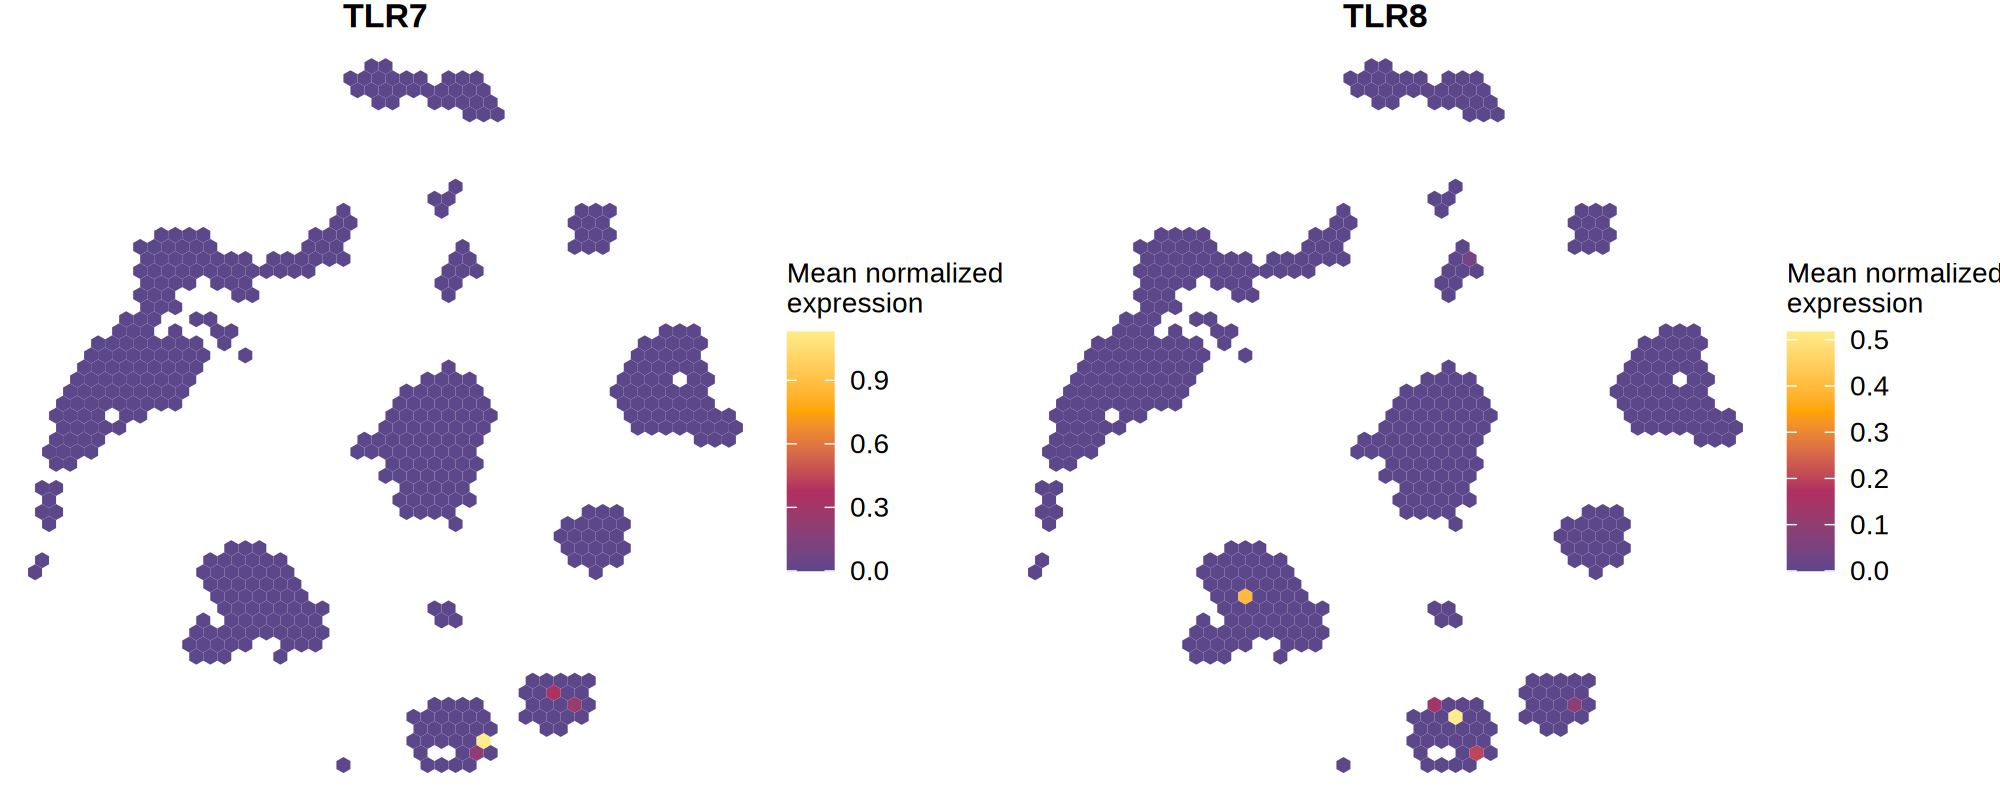

In [5]:
fig.size(4, 10)
plot_genes_hex(obj_NL, quantile_limit = 1, height = 4, width = 10,
               features = c("TLR7", "TLR8"),
               save_path = "../_figures/snRNA_NL_TLR7+8_hex_expression.pdf")

In [6]:
obj_snRNA_Wk0 = obj_snRNA %>% subset(subset = TimePt == 'Wk0')

In [122]:
obj_snRNA_Wk0@meta.data$PatientID = factor(obj_snRNA_Wk0@meta.data$PatientID, levels = paste0('P', 1:10))
obj_snRNA_Wk0@meta.data$Type = factor(obj_snRNA_Wk0@meta.data$Type, levels = c('NL', 'LesUntx'))

# DE LesUntx Week 0 vs. NL Week 0, by cell type

## Seurat FindMarkers 

In [7]:
table(obj_snRNA_Wk0@meta.data$cell_type, obj_snRNA_Wk0@meta.data$Type)

                      
                       LesUntx   NL
  Keratinocyte undiff.     669 1042
  Keratinocyte diff.      1069  648
  Melanocyte               244  292
  Hair follicle            415  696
  Dermal adipocyte           3  235
  Fibroblast              2801 1382
  Pericyte                 296  189
  Vascular EC             2003  952
  Lymphatic EC             613  862
  Mast                     191   79
  Myeloid                 2203  336
  T cell                  4684  334

In [8]:
# Remove spaces, parenthases, and slashes in cell type names
obj_snRNA_Wk0@meta.data$cell_type = gsub("[ /\\(\\)]", ".", obj_snRNA_Wk0@meta.data$cell_type)

Idents(object = obj_snRNA_Wk0) = "cell_type"

In [14]:
# Check if the directory exists and create it if not
res_dir = "../_results/SeuratFindMarkers_Untx/"
if (!dir.exists(res_dir)) {
  dir.create(res_dir)
}

markers = list()

for (ct in unique(obj_snRNA_Wk0@meta.data$cell_type)) {
    suppressWarnings({
    message(ct)
    markers[[ct]] = FindMarkers(obj_snRNA_Wk0, test.use = "wilcox", ident.1 = 'LesUntx',
                      group.by = 'Type', subset.ident = ct, min.pct = 0.1, logfc.threshold = 0.25)
    
    top6 = markers[[ct]] %>% arrange(-abs(avg_log2FC)) %>% head(6)
    p = VlnPlot(object = subset(obj_snRNA_Wk0, idents = ct), 
        features = c(rownames(top6)), 
        group.by = 'PatientID', split.by = 'Type') + theme(legend.position = 'right')
    pdf(file = paste0(res_dir, ct, 'Wk0Untx_vs_Wk0NL.pdf'),
    width = 12, height = 6)
    print(p)
    dev.off()
    })
}

saveRDS(markers, paste0(res_dir, 'markers_Wk0Untx_vs_Wk0NL.rds'))

Pericyte

T.cell

Fibroblast

Vascular.EC

Myeloid

Mast

Melanocyte

Keratinocyte.undiff.

Lymphatic.EC

Keratinocyte.diff.

Hair.follicle

Dermal.adipocyte



## View results

In [16]:
markers = readRDS(paste0(res_dir, 'markers_Wk0Untx_vs_Wk0NL.rds'))
for (ct in unique(obj_snRNA_Wk0@meta.data$cell_type)) {
    markers[[ct]]$cell_type = ct
    markers[[ct]]$gene = rownames(markers[[ct]])
}

png 
  2

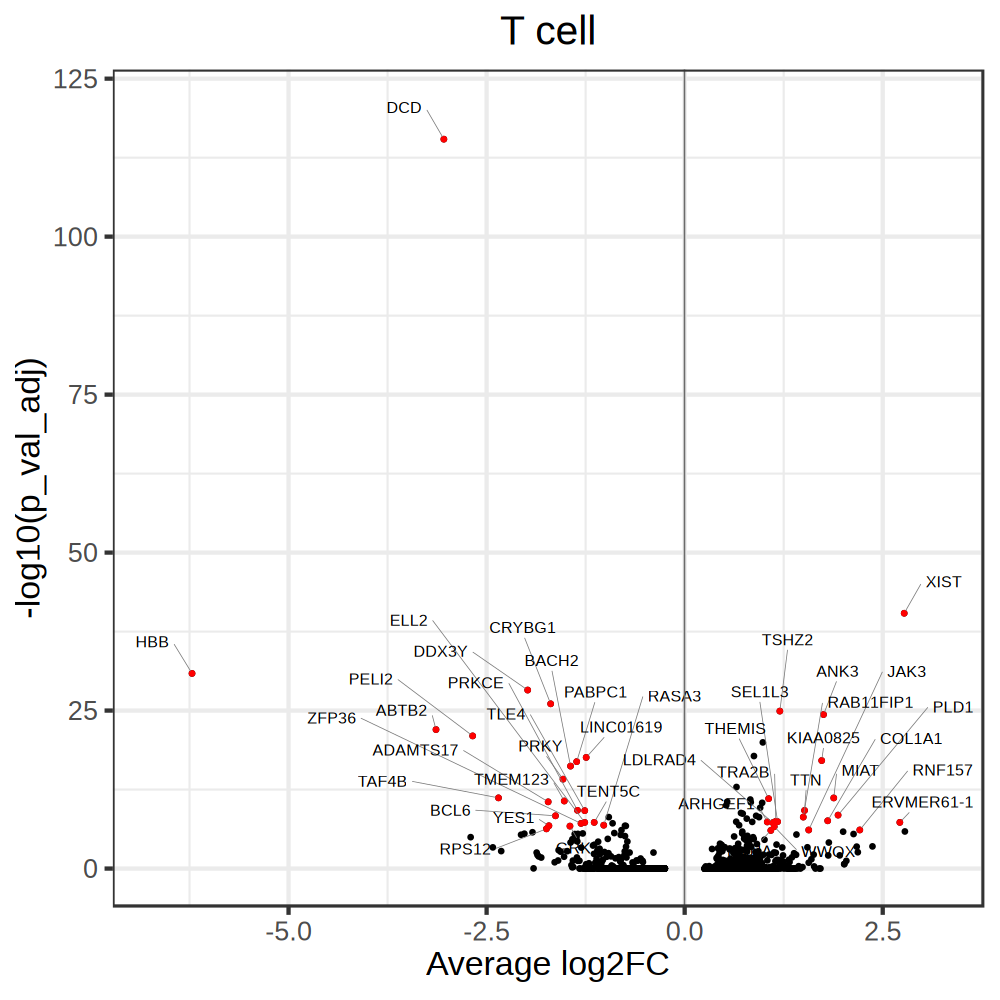

In [17]:
ct = 'T.cell'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.0 & -log10(p_val_adj) > 6)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'T cell', nx = 0.5, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

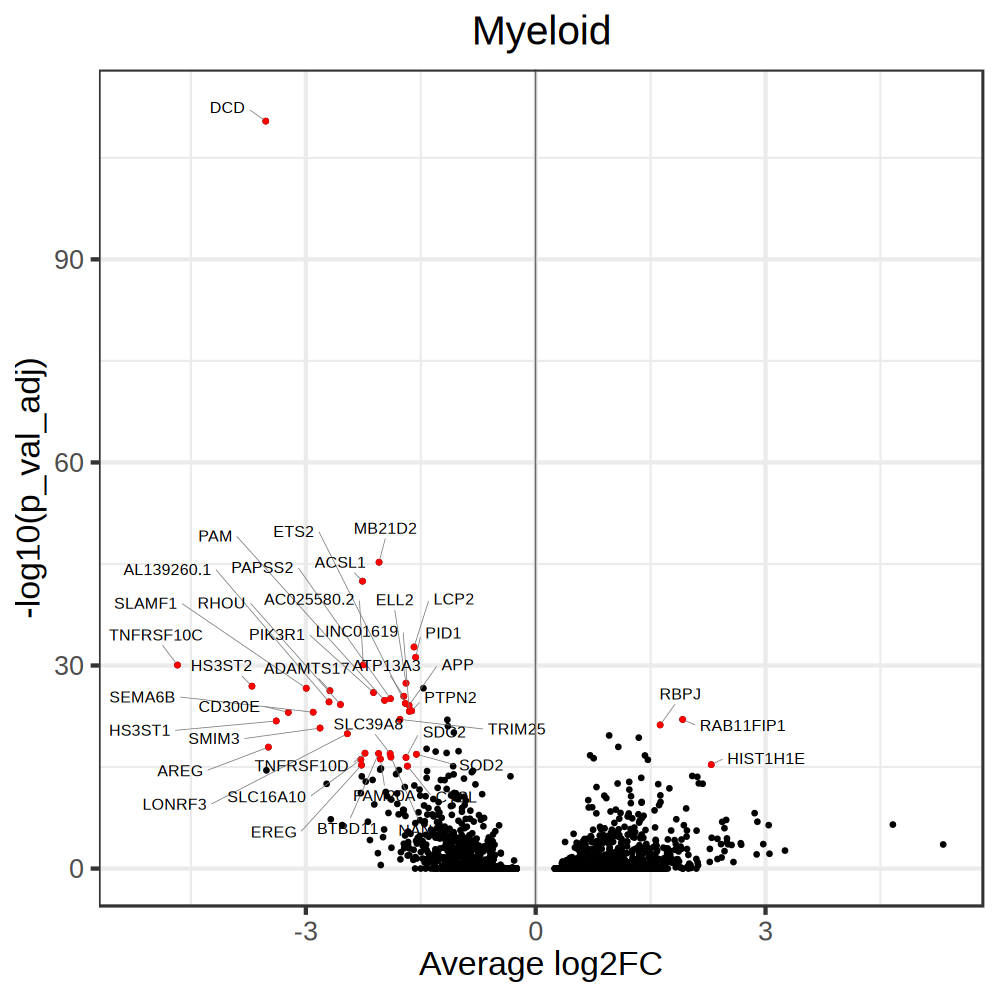

In [19]:
ct = 'Myeloid'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 15)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Myeloid', nx = 0.5, ny = 2)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

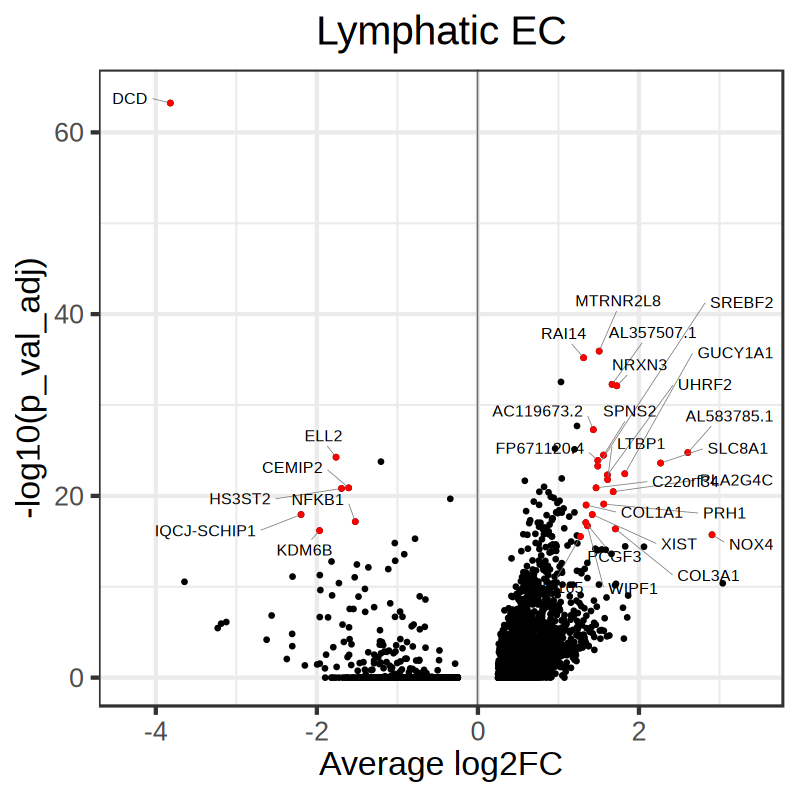

In [20]:
ct = 'Lymphatic.EC'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.25 & -log10(p_val_adj) > 15)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Lymphatic EC', nx = 0.5, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

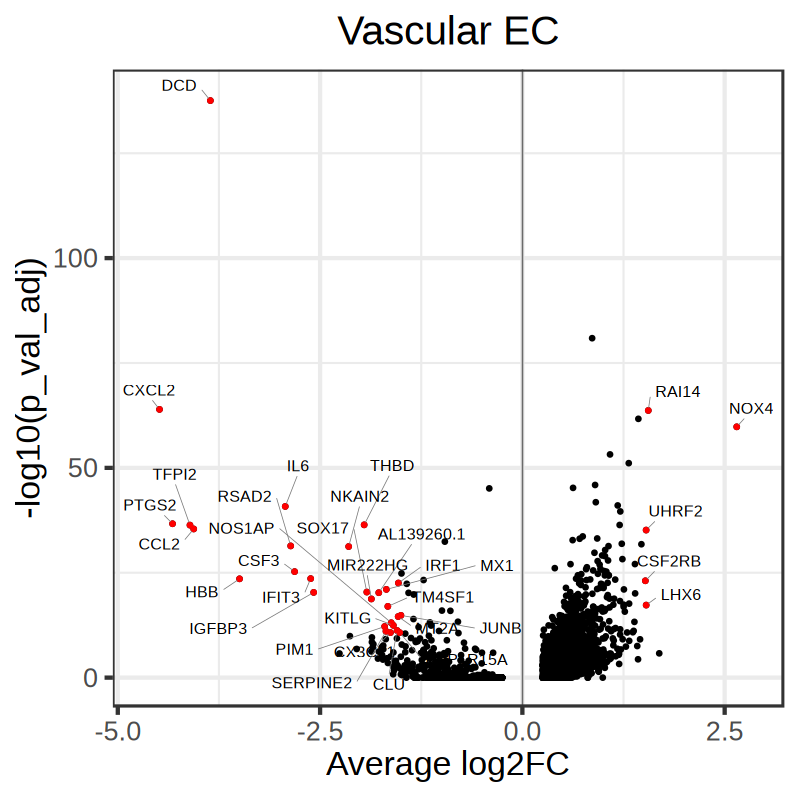

In [21]:
ct = 'Vascular.EC'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 10)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Vascular EC', nx = 0.2, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

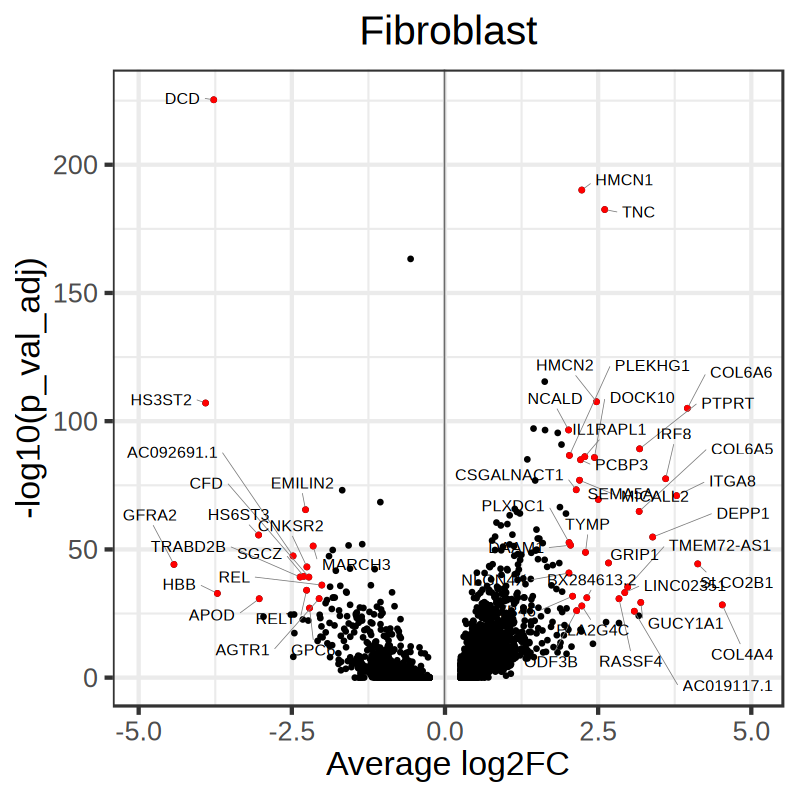

In [22]:
ct = 'Fibroblast'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 2.0 & -log10(p_val_adj) > 25)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Fibroblast', nx = 0.5, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

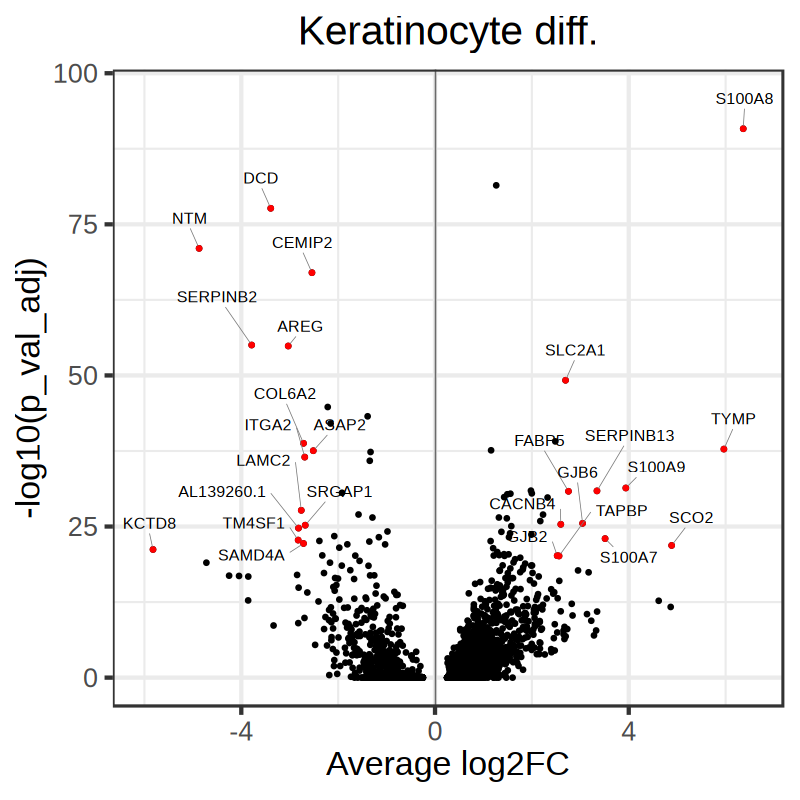

In [23]:
ct = 'Keratinocyte.diff.'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 2.5 & -log10(p_val_adj) > 20)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Keratinocyte diff.', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

S100A8 and S100A9 is interesting (higher in lesional vs. NL)

png 
  2

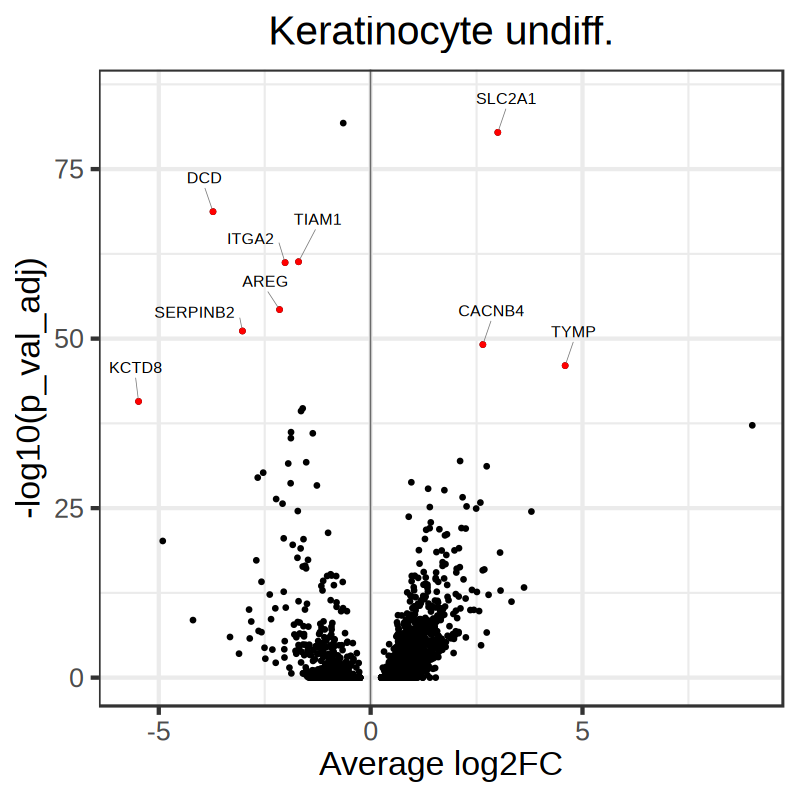

In [24]:
ct = 'Keratinocyte.undiff.'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 40)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Keratinocyte undiff.', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

png 
  2

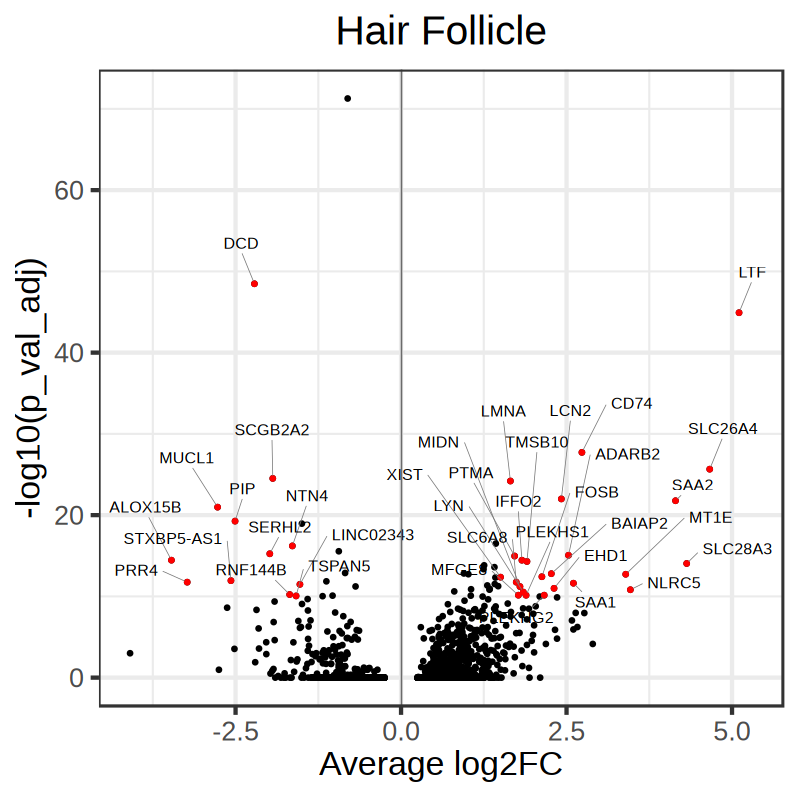

In [25]:
ct = 'Hair.follicle'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 10)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Hair Follicle', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

In [35]:
for (ct in unique(names(markers))) {
    markers_ct = markers[[ct]]
    write.csv(markers_ct, paste0(res_dir, '/Wk0Untx_vs_Wk0NL_', ct, '.csv'))
}

## Violin plots - Pattern across subjects

In [141]:
CustomVlnPlot <- function(seurat_obj, features, group.by = "ident", color.by= 'Type',
                         type_col = "Type", pt.size = 0, combine = TRUE, 
                         cols = c('#8ee6ad', '#ed8866'), y.max = NULL) {
    
    # Extract data for plotting
    plot_data <- FetchData(seurat_obj, 
                          vars = c(features, group.by, type_col)) %>% gather(key = "Feature", value = "Expression", -all_of(c(group.by, type_col)))
    
    # Calculate statistics for violin plot
    stats_data <- plot_data %>%
        group_by(!!sym(group.by), !!sym(type_col), Feature) %>%
        summarise(
            median = median(Expression),
            mean = mean(Expression),
            q25 = quantile(Expression, 0.25),
            q75 = quantile(Expression, 0.75))
    
    # Create plot
    plots <- lapply(features, function(feature) {
        p <- ggplot(plot_data %>% filter(Feature == feature), 
                   aes(x = !!sym(group.by), 
                       y = Expression, 
                       fill = !!sym(color.by))) +
            geom_violin(scale = "width", adjust = 1, trim = TRUE, linewidth = 0.2) +
            geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, linewidth = 0.2) +
            facet_grid(~Type, scales = "free_x", space = "free") +  # Add faceting
            theme_bw(base_size = 11) +
            theme(
                axis.text.x = element_text(angle = 45, hjust = 1, size = 11),
                legend.position = "none",
                panel.grid.major.x = element_blank(),
                panel.grid.minor.x = element_blank()) +
            labs(title = feature, x = NULL, y = "Expression Level") +
            theme(strip.text.x = element_text(size = 11))
        
        # Add points if requested
        if(pt.size > 0) {
            p <- p + geom_jitter(size = pt.size, alpha = 0.2, width = 0.2)
        }
        
        ## Add custom colors if provided
        if(!is.null(cols)) {
            p <- p + scale_fill_manual(values = cols)
        }
        
        # Set y axis limit if provided
        if(!is.null(y.max)) {
            p <- p + coord_cartesian(ylim = c(0, y.max))
        }
        return(p)
    })
    
    # Combine plots if requested
    if(combine && length(features) > 1) {
        return(wrap_plots(plots, ncol = min(length(features), 2)))
    } else {
        return(plots)
    }
}

`summarise()` has grouped output by 'PatientID', 'Type'. You can override using
the `.groups` argument.


png 
  2

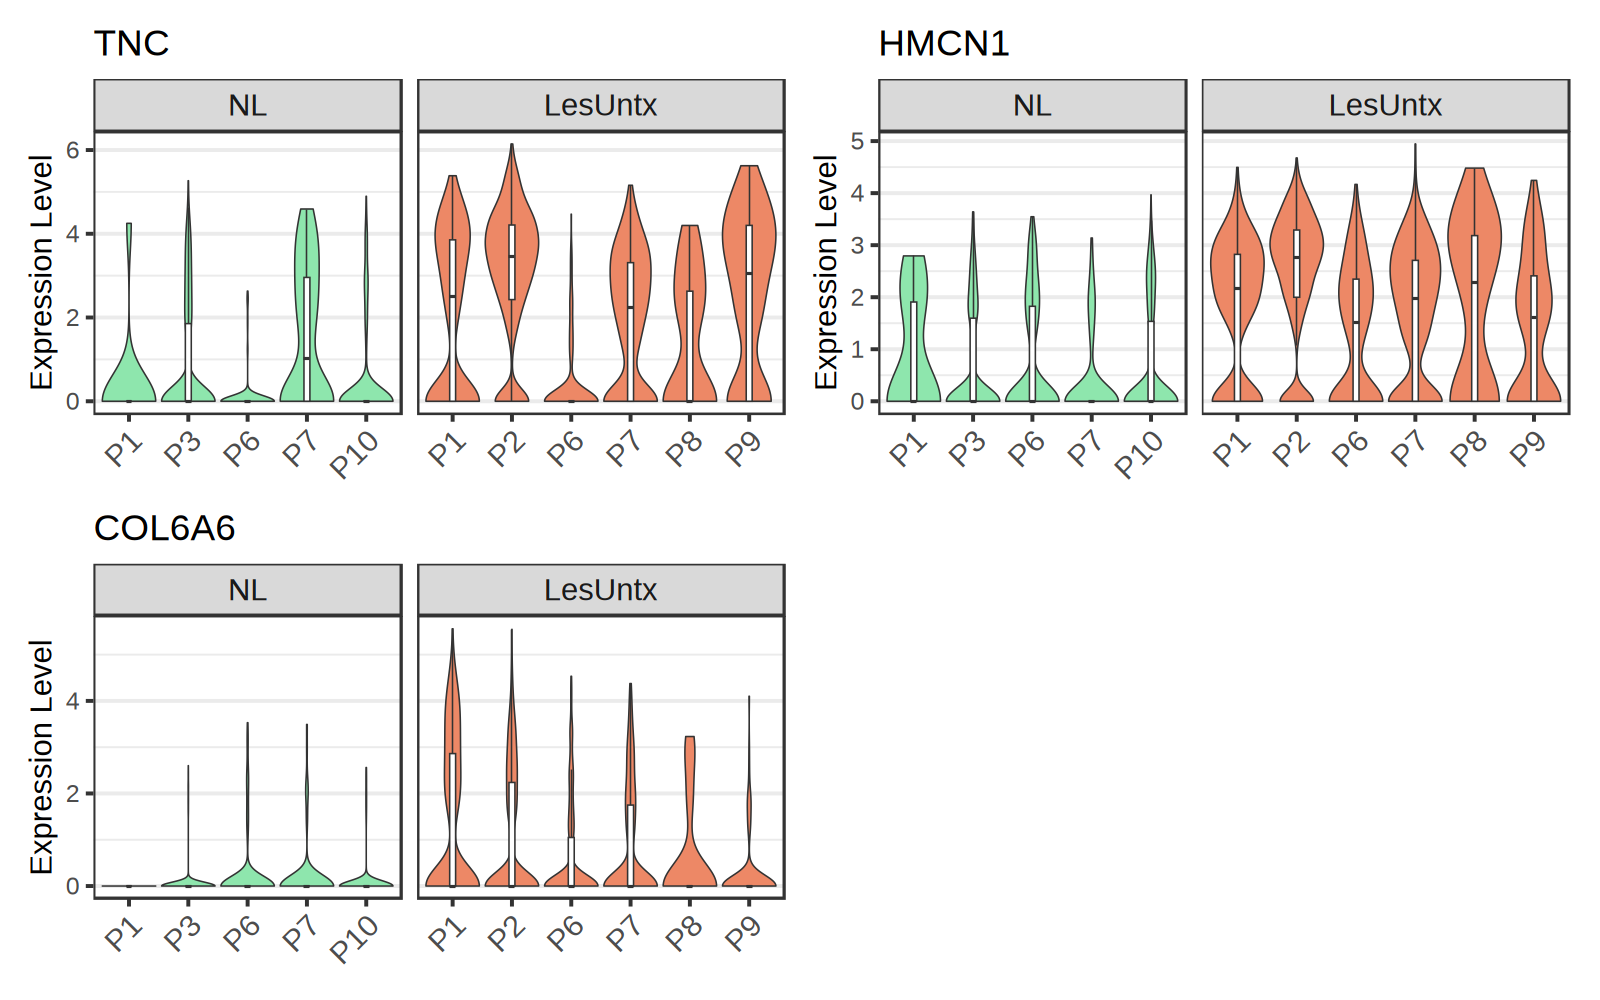

In [148]:
fig.size(5, 8)
obj_F = subset(obj_snRNA_Wk0, subset = cell_type == 'Fibroblast')
p = CustomVlnPlot(obj_F, 
             features = c('TNC', 'HMCN1', 'COL6A6'), 
             group.by = "PatientID",
             type_col = "Type") 
pdf('../_figures/violins_untx/Fibroblast_UntxVsNL_selected_genes.pdf', width = 8, height = 5)
print(p)
dev.off()
p

`summarise()` has grouped output by 'Subject', 'Type'. You can override using
the `.groups` argument.


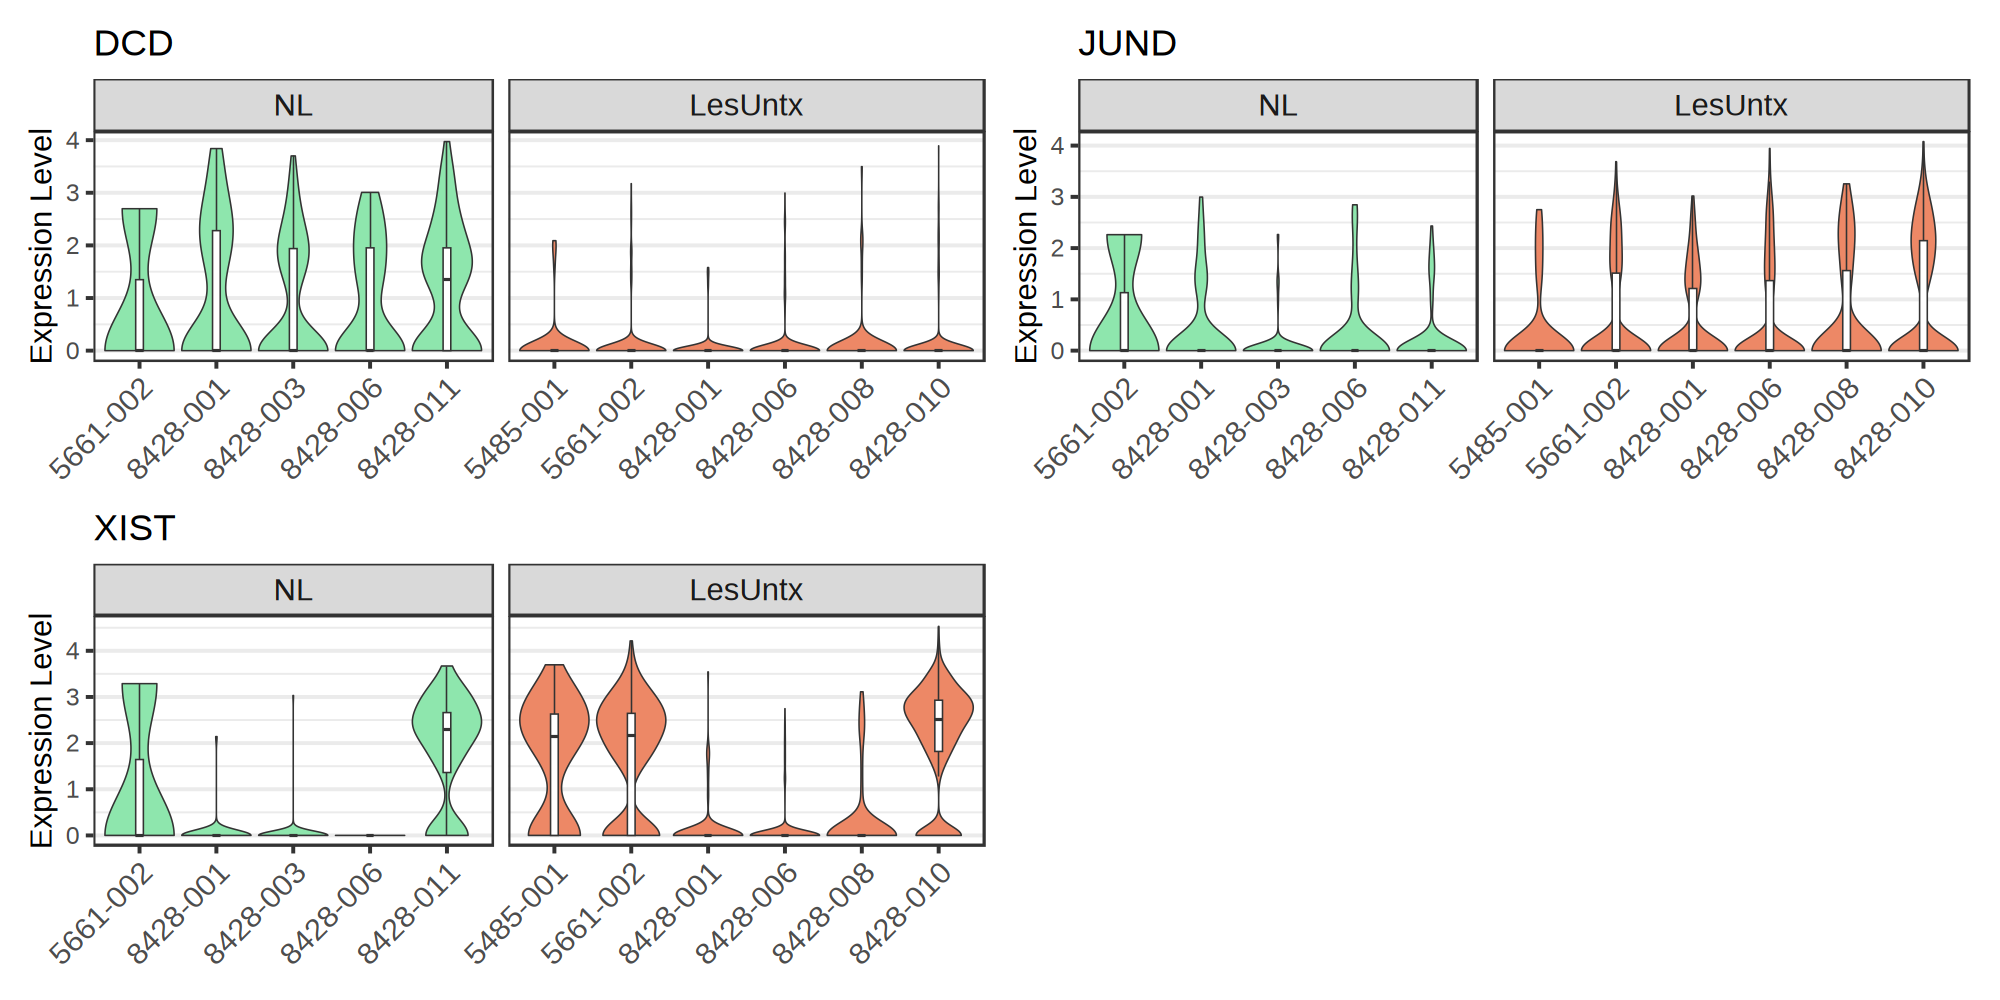

In [143]:
fig.size(5, 10)
obj_M = subset(obj_snRNA_Wk0, subset = cell_type == 'Myeloid')
CustomVlnPlot(obj_M, 
             features = c('DCD', 'JUND', 'XIST'), 
             group.by = "Subject",
             type_col = "Type")  # specify your Type column name

`summarise()` has grouped output by 'Subject', 'Type'. You can override using
the `.groups` argument.


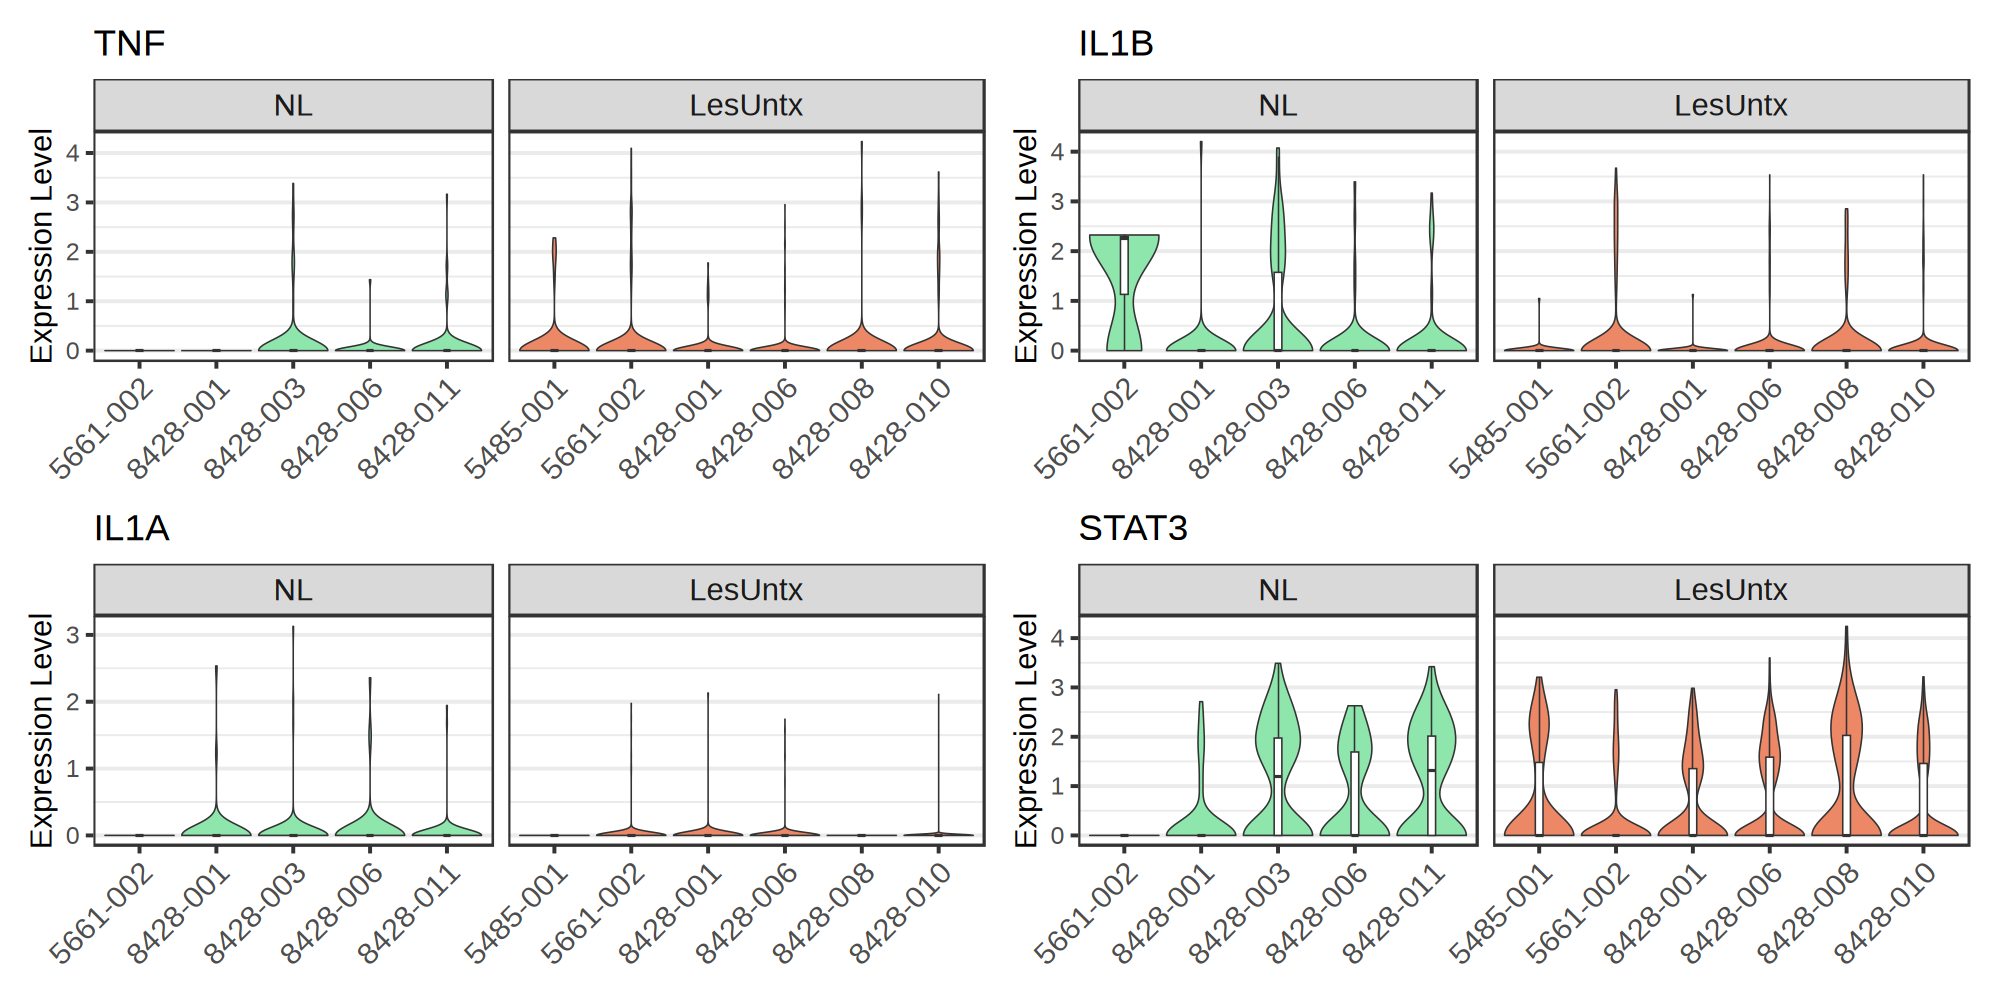

In [144]:
fig.size(5, 10)
obj_M = subset(obj_snRNA_Wk0, subset = cell_type == 'Myeloid')
CustomVlnPlot(obj_M, 
             features = c('TNF', "IL1B", "IL1A", "STAT3"), 
             group.by = "Subject",
             type_col = "Type")  # specify your Type column name

`summarise()` has grouped output by 'PatientID', 'Type'. You can override using
the `.groups` argument.


png 
  2

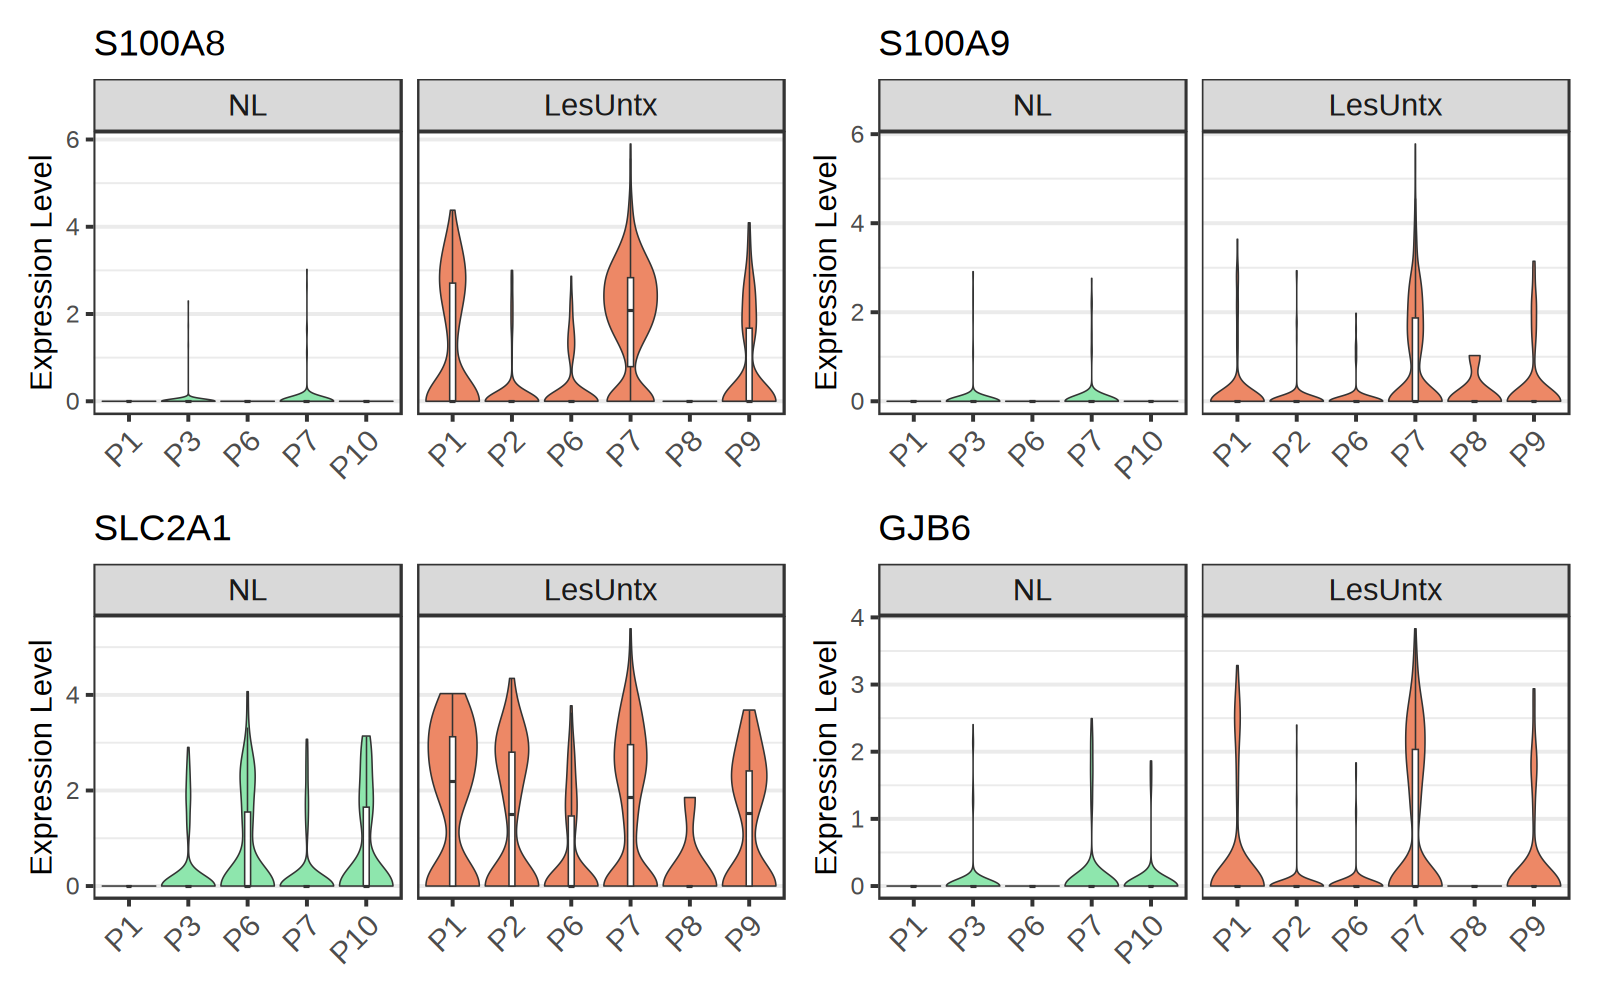

In [145]:
fig.size(5, 8)
obj_K = subset(obj_snRNA_Wk0, subset = cell_type == 'Keratinocyte.diff.')
p = CustomVlnPlot(obj_K, 
             features = c('S100A8', "S100A9", "SLC2A1", "GJB6"), 
             group.by = "PatientID",
             type_col = "Type")  # specify your Type column name
pdf('../_figures/violins_untx/Keratinocyte.diff_UntxVsNL_selected_genes.pdf', width = 8, height = 5)
print(p)
dev.off()
p

`summarise()` has grouped output by 'PatientID', 'Type'. You can override using
the `.groups` argument.


png 
  2

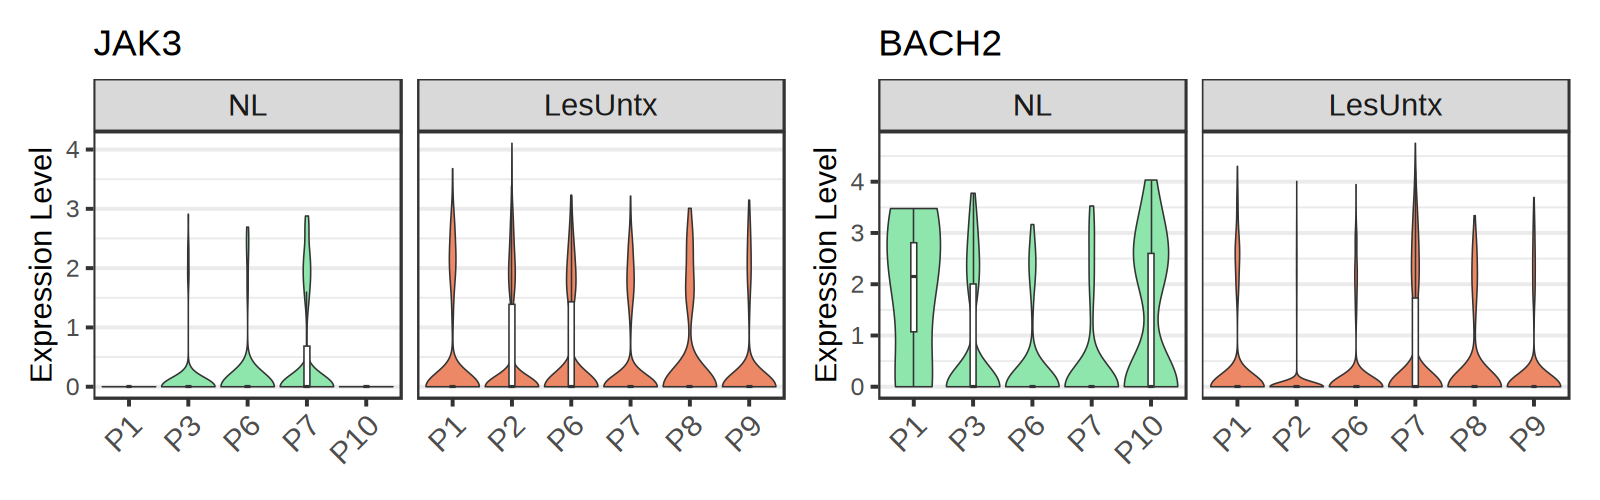

In [146]:
fig.size(2.5, 8)
obj_T = subset(obj_snRNA_Wk0, subset = cell_type == 'T.cell')
p = CustomVlnPlot(obj_T, 
             features = c('JAK3', 'BACH2'), 
             group.by = "PatientID",
             type_col = "Type")  # specify your Type column name
pdf('../_figures/violins_untx/T_UntxVsNL_selected_genes.pdf', width = 8, height = 2.5)
print(p)
dev.off()
p

# GSEA

In [45]:
Wk0UntxvsW0NL = readRDS('../_results/SeuratFindMarkers_Untx/markers_Wk0Untx_vs_Wk0NL.rds')

In [46]:
# run_GSEA_on_list is defined in utils.R

In [47]:
gene_sets = load_gene_sets()
hallmark_gene_sets = gene_sets$hallmark
all_gene_sets = gene_sets$all

In [48]:
unique(all_gene_sets$gs_name) %>% length()
unique(hallmark_gene_sets$gs_name) %>% length()

[1] 7894

[1] 50

In [50]:
set.seed(1)
suppressMessages({ suppressWarnings({
run_GSEA_on_list(Wk0UntxvsW0NL, out_dir = "../_results/GSEA_Untx_vs_NL/hallmark_gs", label = "Wk0Untx_vs_Wk0NL", gene_set = hallmark_gene_sets, plot_width = 12)
run_GSEA_on_list(Wk0UntxvsW0NL, out_dir = "../_results/GSEA_Untx_vs_NL/all_gs",      label = "Wk0Untx_vs_Wk0NL", gene_set = all_gene_sets,      plot_width = 12)
}) })

# Write DE results to .csv files for IPA

In [52]:
save_to_csvs(Wk0UntxvsW0NL, out_dir = '../_results/SeuratDEFormatforIPA/LesUntx_vs_NL_Wk0')

In [149]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /PHShome/jbk37/anaconda3/envs/resiq1/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] DESeq2_1.42.1               EnhancedVolcano_1.20.0     
 [3] rlang_1.1.3                 org.Hs.eg.db_3.18.0        
 [5] AnnotationDbi_1.64.1        msigdbr_7.5.1              
 [7] clusterProfiler